# SagingSense: A Convolutional Neural Network-Based Banana Ripeness Classification System for Fruit Quality Assessment

This notebook develops the first machine learning model for SagingSense.

The goal is to classify banana images according to ripeness stage using a Convolutional Neural Network, or CNN.

## Dataset

Dataset: Banana Ripeness Classification Dataset  
Task: Banana ripeness image classification  
Total Images: 13,478 images  
Source: Kaggle  

## Main Workflow

1. Load the banana image dataset
2. Inspect dataset folders and image counts
3. Prepare training, validation, and testing sets
4. Build a CNN model
5. Train the model
6. Evaluate model performance
7. Display the confusion matrix and classification report
8. Check wrong predictions

### Import Libraries

In [7]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.18.0
GPU devices: []


### Set Dataset Path

In [8]:
# ============================================================
# DATASET PATH CONFIGURATION
# ============================================================
from pathlib import Path

DATASET_NAME = "banana-ripeness-classification-dataset"
candidates = []

# Search from current directory upward so this works regardless of where Jupyter was launched.
for base in [Path.cwd(), *Path.cwd().parents]:
    candidates.append(base / "kaggle" / "input" / DATASET_NAME)

# Kaggle notebook absolute path fallback.
candidates.append(Path("/kaggle/input") / DATASET_NAME)

DATASET_ROOT = next((c for c in candidates if c.exists()), None)

if DATASET_ROOT is None:
    checked = "\n".join(str(c) for c in candidates)
    raise FileNotFoundError(
        "Could not locate dataset folder. Checked:\n"
        f"{checked}\n"
        f"Current working directory: {Path.cwd()}"
    )

print("Dataset root:", DATASET_ROOT)


Dataset root: E:\GitHub\SagingSense\kaggle\input\banana-ripeness-classification-dataset


### Inspect Dataset Folder Structure

In [9]:
print("Files and folders inside dataset root:\n")

for item in DATASET_ROOT.iterdir():
    if item.is_dir():
        print("[DIR] ", item.name)
    else:
        print("[FILE]", item.name)

Files and folders inside dataset root:

[DIR]  test
[DIR]  train
[DIR]  valid


### Automatically Find the Image Folder

In [10]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images_in_class_folders(folder):
    folder = Path(folder)
    class_counts = {}
    for subfolder in sorted(folder.iterdir()):
        if subfolder.is_dir():
            image_count = sum(
                1 for file in subfolder.rglob("*")
                if file.suffix.lower() in IMAGE_EXTENSIONS
            )
            if image_count > 0:
                class_counts[subfolder.name] = image_count
    return class_counts

required_splits = ["train", "valid", "test"]
split_dirs = {split: DATASET_ROOT / split for split in required_splits}

missing = [split for split, path in split_dirs.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        f"Missing required split folder(s): {missing}\n"
        f"Expected under: {DATASET_ROOT}"
    )

split_class_counts = {split: count_images_in_class_folders(path) for split, path in split_dirs.items()}

empty_splits = [split for split, counts in split_class_counts.items() if len(counts) < 2]
if empty_splits:
    raise ValueError(
        f"These split folders do not contain enough class subfolders with images: {empty_splits}"
    )

class_sets = {split: set(counts.keys()) for split, counts in split_class_counts.items()}
if not (class_sets["train"] == class_sets["valid"] == class_sets["test"]):
    raise ValueError(
        "Class folder mismatch across splits.\n"
        f"train={sorted(class_sets['train'])}\n"
        f"valid={sorted(class_sets['valid'])}\n"
        f"test={sorted(class_sets['test'])}"
    )

CLASS_NAMES = sorted(class_sets["train"])
TRAIN_DIR = split_dirs["train"]
VALID_DIR = split_dirs["valid"]
TEST_DIR = split_dirs["test"]

print("Detected split directories:")
print("TRAIN_DIR:", TRAIN_DIR)
print("VALID_DIR:", VALID_DIR)
print("TEST_DIR :", TEST_DIR)

print("\nDetected classes:", CLASS_NAMES)

for split in required_splits:
    counts = split_class_counts[split]
    total = sum(counts.values())
    print(f"\n{split.upper()} ({total} images):")
    for class_name in CLASS_NAMES:
        print(f"  {class_name}: {counts.get(class_name, 0)}")


Detected split directories:
TRAIN_DIR: E:\GitHub\SagingSense\kaggle\input\banana-ripeness-classification-dataset\train
VALID_DIR: E:\GitHub\SagingSense\kaggle\input\banana-ripeness-classification-dataset\valid
TEST_DIR : E:\GitHub\SagingSense\kaggle\input\banana-ripeness-classification-dataset\test

Detected classes: ['overripe', 'ripe', 'rotten', 'unripe']

TRAIN (11793 images):
  overripe: 2349
  ripe: 3522
  rotten: 4020
  unripe: 1902

VALID (1123 images):
  overripe: 229
  ripe: 339
  rotten: 388
  unripe: 167

TEST (562 images):
  overripe: 113
  ripe: 154
  rotten: 185
  unripe: 110


### Create Dataset Table

In [ ]:
dataset_summary = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Image Count (Train)": [split_class_counts["train"][class_name] for class_name in CLASS_NAMES],
    "Image Count (Valid)": [split_class_counts["valid"][class_name] for class_name in CLASS_NAMES],
    "Image Count (Test)": [split_class_counts["test"][class_name] for class_name in CLASS_NAMES]
})

dataset_summary["Total"] = (
    dataset_summary["Image Count (Train)"] +
    dataset_summary["Image Count (Valid)"] +
    dataset_summary["Image Count (Test)"]
)

dataset_summary["Percentage"] = (
    dataset_summary["Total"] / dataset_summary["Total"].sum() * 100
).round(2)

print("Dataset Summary:")
print(dataset_summary.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(dataset_summary["Class"], dataset_summary["Total"])
plt.title("Number of Images per Banana Ripeness Class (All Splits)")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Build File List

In [ ]:
class_names = list(CLASS_NAMES)
class_to_index = {class_name: index for index, class_name in enumerate(class_names)}
index_to_class = {index: class_name for class_name, index in class_to_index.items()}

def collect_split_data(split_name):
    split_path = split_dirs[split_name]
    split_paths = []
    split_labels = []
    for class_name in class_names:
        class_folder = split_path / class_name
        for file in class_folder.rglob("*"):
            if file.suffix.lower() in IMAGE_EXTENSIONS:
                split_paths.append(str(file))
                split_labels.append(class_to_index[class_name])
    return np.array(split_paths), np.array(split_labels)

# Use the dataset's provided split folders directly.
X_train, y_train = collect_split_data("train")
X_val, y_val = collect_split_data("valid")
X_test, y_test = collect_split_data("test")

# Combined arrays are kept for visualization compatibility.
image_paths = np.concatenate([X_train, X_val, X_test])
labels = np.concatenate([y_train, y_val, y_test])

print("Total image paths:", len(image_paths))
print("Total labels:", len(labels))
print("Classes:", class_names)
print("Class to index mapping:", class_to_index)
print("Split sizes -> train:", len(X_train), "valid:", len(X_val), "test:", len(X_test))


### Show Sample Images

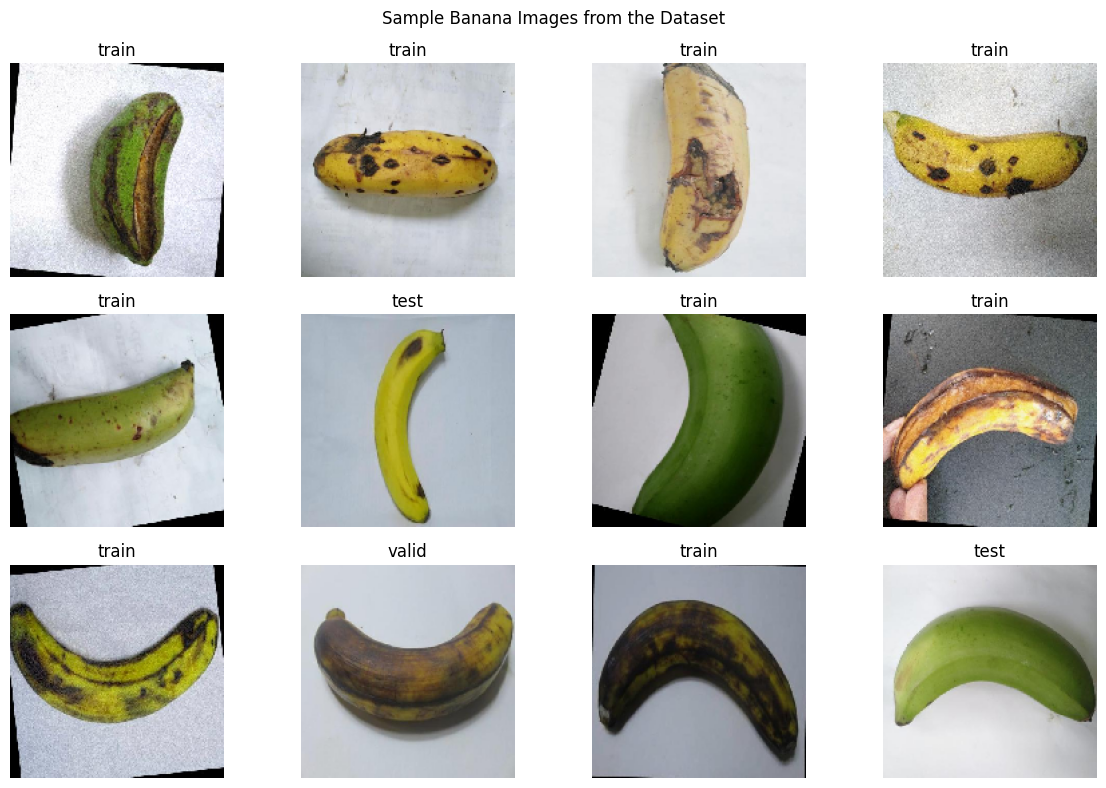

In [13]:
plt.figure(figsize=(12, 8))

sample_indices = random.sample(range(len(image_paths)), min(12, len(image_paths)))

for plot_index, image_index in enumerate(sample_indices):
    img = keras.utils.load_img(image_paths[image_index], target_size=(160, 160))
    label_name = index_to_class[labels[image_index]]

    plt.subplot(3, 4, plot_index + 1)
    plt.imshow(img)
    plt.title(label_name)
    plt.axis("off")

plt.suptitle("Sample Banana Images from the Dataset")
plt.tight_layout()
plt.show()

### Use Dataset's Existing Training, Validation, and Testing Splits

This notebook uses the original dataset split folders directly: `train`, `valid`, and `test`.


In [ ]:
# Keep the original dataset split (no random re-splitting).
print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Testing images:", len(X_test))

print("\nClass distribution in training set:")
print(pd.Series(y_train).map(index_to_class).value_counts())

print("\nClass distribution in validation set:")
print(pd.Series(y_val).map(index_to_class).value_counts())

print("\nClass distribution in testing set:")
print(pd.Series(y_test).map(index_to_class).value_counts())


### Create TensorFlow Datasets

In [16]:
IMG_SIZE = 160
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def create_tf_dataset(paths, labels, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(paths), seed=42)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_ds = create_tf_dataset(X_train, y_train, shuffle=True)
val_ds = create_tf_dataset(X_val, y_val, shuffle=False)
test_ds = create_tf_dataset(X_test, y_test, shuffle=False)

print("\n Training dataset:", train_ds)
print("\n Validation dataset:", val_ds)
print("\n Testing dataset:", test_ds)


 Training dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

 Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

 Testing dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


### CNN means Convolutional Neural Network.

A CNN learns visual patterns such as:

- Convolution	-> Detects edges, spots, textures, and color patterns
- Max Pooling	-> Reduces image size while keeping important features
- Batch Normalization	-> Stabilizes training
- Dropout	-> Reduces overfitting
- Dense Layer	-> Performs final classification

In [18]:
num_classes = len(class_names)

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation"
)

model = keras.Sequential(
    [
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        data_augmentation,

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.40),

        layers.Dense(num_classes, activation="softmax")
    ],
    name="SagingSense_CNN"
)

model.summary()

Model: "SagingSense_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 160, 160, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 160, 160, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 80, 80, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 80, 80, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 80, 80, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 40, 40, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 40, 40, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 40, 40, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 20, 20, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 20, 20, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 10, 10, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 456,899 (1.74 MB)

 Trainable params: 455,939 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

### Compile the Model

The loss function used is sparse categorical cross-entropy, which is commonly used for multi-class classification.

In [31]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Train the Model

In [32]:
EPOCHS = 20

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 151s 477ms/step - accuracy: 0.8811 - loss: 0.4080 - val_accuracy: 0.8749 - val_loss: 0.4880 - learning_rate: 0.0010
Epoch 2/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 143s 481ms/step - accuracy: 0.8721 - loss: 0.4079 - val_accuracy: 0.8749 - val_loss: 0.5331 - learning_rate: 0.0010
Epoch 3/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 148s 495ms/step - accuracy: 0.8735 - loss: 0.4140 - val_accuracy: 0.8749 - val_loss: 0.4168 - learning_rate: 0.0010
Epoch 4/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 148s 496ms/step - accuracy: 0.8748 - loss: 0.3993 - val_accuracy: 0.8749 - val_loss: 0.4121 - learning_rate: 0.0010
Epoch 5/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 151s 505ms/step - accuracy: 0.8806 - loss: 0.3890 - val_accuracy: 0.8749 - val_loss: 0.3990 - learning_rate: 0.0010
Epoch 6/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 153s 513ms/step - accuracy: 0.8750 - loss: 0.3936 - val_accuracy: 0.8749 - val_loss: 0.4335 - learning_rate: 0.0010
Epoch 7/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 144s 482ms/step - accura

### Plot Training Results

    accuracy      loss  val_accuracy  val_loss  learning_rate
0   0.874920  0.419425      0.874876  0.488021         0.0010
1   0.875027  0.405890      0.874876  0.533112         0.0010
2   0.875027  0.409481      0.874876  0.416831         0.0010
3   0.875027  0.398823      0.874876  0.412119         0.0010
4   0.875027  0.400421      0.874876  0.399004         0.0010
5   0.875027  0.395369      0.874876  0.433509         0.0010
6   0.875027  0.392718      0.874876  0.396629         0.0010
7   0.875027  0.392263      0.874876  0.474550         0.0010
8   0.875027  0.397934      0.874876  0.485639         0.0010
9   0.875027  0.391164      0.874876  0.373183         0.0010
10  0.874815  0.389239      0.874876  0.447459         0.0010
11  0.875027  0.388466      0.874876  0.436350         0.0010
12  0.875027  0.388791      0.874876  0.418604         0.0010
13  0.875027  0.377146      0.874876  0.393612         0.0003
14  0.875027  0.374250      0.874876  0.375006         0.0003


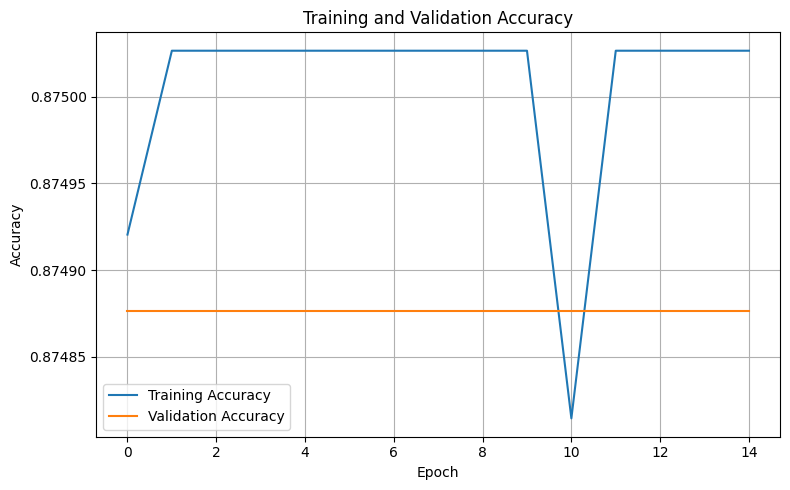

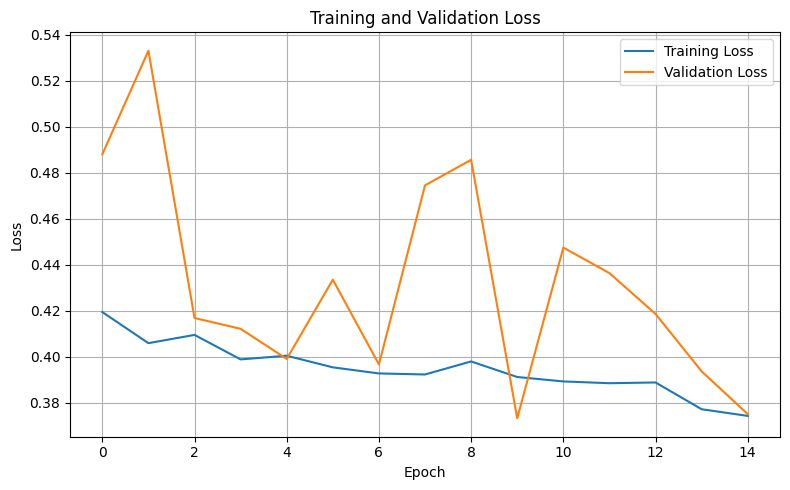

In [33]:
history_df = pd.DataFrame(history.history)

print(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Evaluate on Test Set

In [34]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.8843 - loss: 0.3675
Test Loss: 0.383
Test Accuracy: 0.8749


### Generate Predictions

In [35]:
y_true = []
y_pred = []
y_prob = []

for images, labels_batch in test_ds:
    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)
    predicted_confidence = np.max(predictions, axis=1)

    y_true.extend(labels_batch.numpy())
    y_pred.extend(predicted_labels)
    y_prob.extend(predicted_confidence)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Predictions generated:", len(y_pred))

Predictions generated: 2022


### Classification Report
F1-score means F1 measure, a balance between precision and recall.

In [36]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print("Classification Report:")
print(report_df.round(4))

Classification Report:
              precision  recall  f1-score    support
test             0.0000  0.0000    0.0000    85.0000
train            0.8749  1.0000    0.9333  1769.0000
valid            0.0000  0.0000    0.0000   168.0000
accuracy         0.8749  0.8749    0.8749     0.8749
macro avg        0.2916  0.3333    0.3111  2022.0000
weighted avg     0.7654  0.8749    0.8165  2022.0000


C:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

### Confusion Matrix

Confusion Matrix:
             Predicted: test  Predicted: train  Predicted: valid
True: test                 0                85                 0
True: train                0              1769                 0
True: valid                0               168                 0


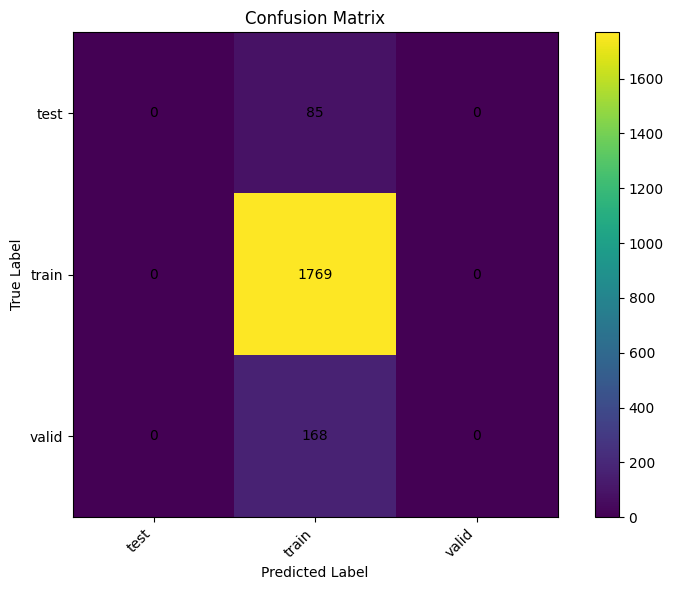

In [37]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"True: {name}" for name in class_names],
    columns=[f"Predicted: {name}" for name in class_names]
)

print("Confusion Matrix:")
print(cm_df)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            horizontalalignment="center",
            verticalalignment="center"
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

### Show Correct and Incorrect Prediction Counts

In [38]:
results_df = pd.DataFrame({
    "Image Path": X_test,
    "True Label Index": y_true,
    "Predicted Label Index": y_pred,
    "Confidence": y_prob
})

results_df["True Label"] = results_df["True Label Index"].map(index_to_class)
results_df["Predicted Label"] = results_df["Predicted Label Index"].map(index_to_class)
results_df["Correct"] = results_df["True Label Index"] == results_df["Predicted Label Index"]

total_correct = results_df["Correct"].sum()
total_wrong = len(results_df) - total_correct

print("Total test images:", len(results_df))
print("Correct predictions:", total_correct)
print("Wrong predictions:", total_wrong)
print("Test accuracy from table:", round(total_correct / len(results_df), 4))

print("\nCorrect and wrong count per class:")
summary_by_class = results_df.groupby("True Label")["Correct"].value_counts().unstack(fill_value=0)
print(summary_by_class)

Total test images: 2022
Correct predictions: 1769
Wrong predictions: 253
Test accuracy from table: 0.8749

Correct and wrong count per class:
Correct     False  True 
True Label              
test           85      0
train           0   1769
valid         168      0


### Display Wrong Predictions

Number of wrong predictions: 253


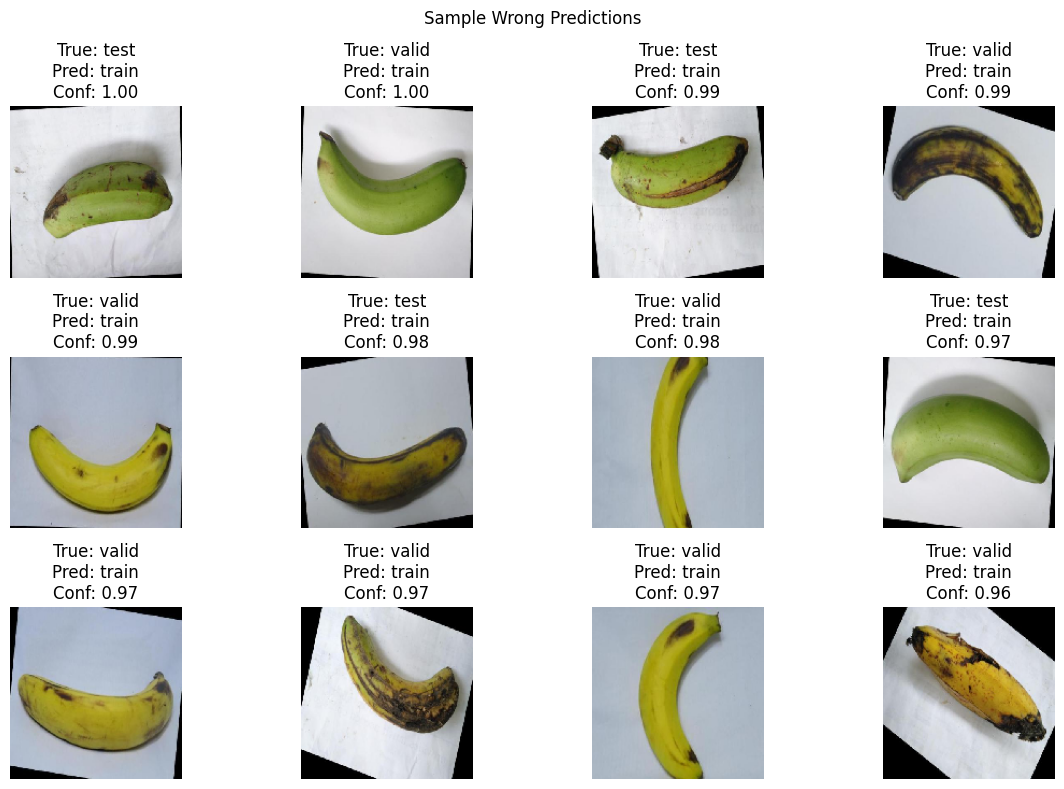

In [39]:
wrong_predictions = results_df[results_df["Correct"] == False].copy()
wrong_predictions = wrong_predictions.sort_values("Confidence", ascending=False)

print("Number of wrong predictions:", len(wrong_predictions))

sample_wrong = wrong_predictions.head(12)

if len(sample_wrong) == 0:
    print("No wrong predictions found.")
else:
    plt.figure(figsize=(12, 8))

    for plot_index, (_, row) in enumerate(sample_wrong.iterrows()):
        img = keras.utils.load_img(row["Image Path"], target_size=(160, 160))

        plt.subplot(3, 4, plot_index + 1)
        plt.imshow(img)
        plt.title(
            f"True: {row['True Label']}\n"
            f"Pred: {row['Predicted Label']}\n"
            f"Conf: {row['Confidence']:.2f}"
        )
        plt.axis("off")

    plt.suptitle("Sample Wrong Predictions")
    plt.tight_layout()
    plt.show()

### Single Image Prediction Function

Sample image: E:\GitHub\SagingSense\kaggle\input\banana-ripeness-classification-dataset\test\ripe\musa-acuminata-freshripe-7c53d864-1d0a-11ec-82e5-d8c4975e38aa_jpg.rf.497d2d215110669fc5cebc6d1cc1d112.jpg
Prediction result:
{'predicted_class': 'train', 'confidence': 0.8805460333824158, 'all_probabilities': {'test': 0.05418030545115471, 'train': 0.8805460333824158, 'valid': 0.06527364999055862}}


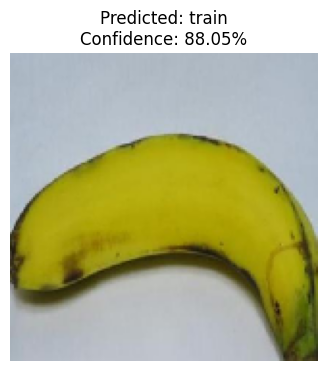

In [40]:
def predict_banana_ripeness(image_path):
    image = keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    image_array = keras.utils.img_to_array(image)
    image_array = image_array / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    prediction = model.predict(image_array, verbose=0)[0]

    predicted_index = int(np.argmax(prediction))
    predicted_class = index_to_class[predicted_index]
    confidence = float(np.max(prediction))

    return {
        "predicted_class": predicted_class,
        "confidence": confidence,
        "all_probabilities": {
            index_to_class[i]: float(prediction[i])
            for i in range(len(class_names))
        }
    }


# Test the function using one test image
sample_image = X_test[0]
prediction_result = predict_banana_ripeness(sample_image)

print("Sample image:", sample_image)
print("Prediction result:")
print(prediction_result)

img = keras.utils.load_img(sample_image, target_size=(160, 160))
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(
    f"Predicted: {prediction_result['predicted_class']}\n"
    f"Confidence: {prediction_result['confidence']:.2%}"
)
plt.axis("off")
plt.show()

### Recommendation Logic

In [41]:
def get_recommendation(predicted_class):
    class_name = predicted_class.lower()

    if "unripe" in class_name or "green" in class_name:
        return "The banana may not be ready for immediate consumption. It is better for storage or later use."

    if "ripe" in class_name and "over" not in class_name:
        return "The banana appears suitable for immediate consumption or selling."

    if "overripe" in class_name or "over ripe" in class_name:
        return "The banana should be consumed soon. It may be suitable for smoothies, baking, or processing."

    if "rotten" in class_name or "bad" in class_name or "decay" in class_name:
        return "The banana may no longer be suitable for consumption."

    return "The banana ripeness stage was classified. Please inspect the image and confidence score for final decision."


sample_prediction = prediction_result["predicted_class"]
recommendation = get_recommendation(sample_prediction)

print("Predicted class:", sample_prediction)
print("Recommendation:", recommendation)

Predicted class: train
Recommendation: The banana ripeness stage was classified. Please inspect the image and confidence score for final decision.
